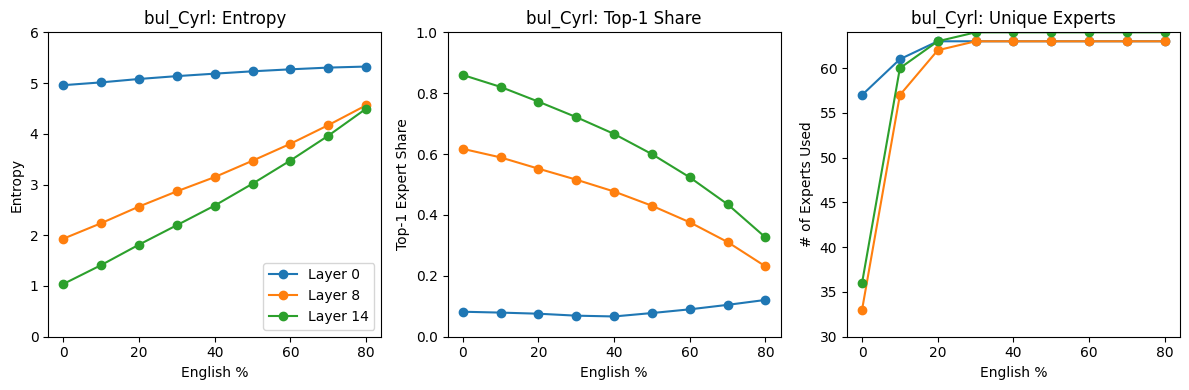

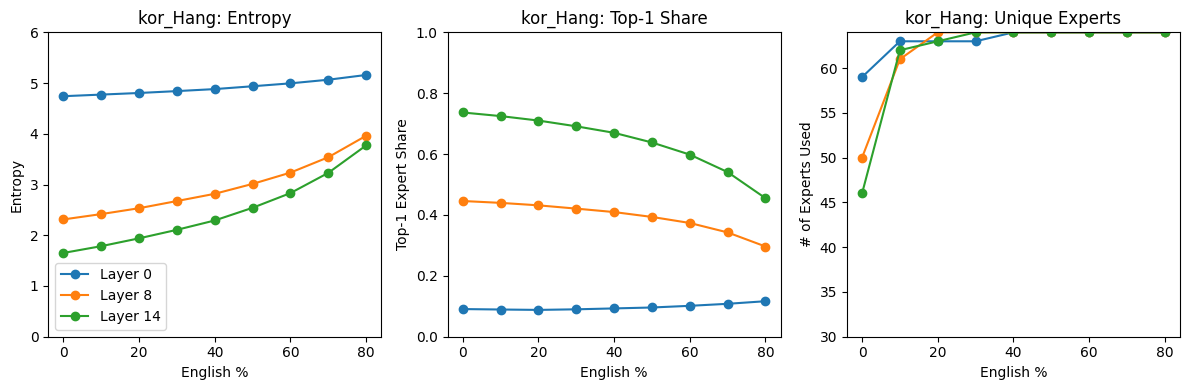

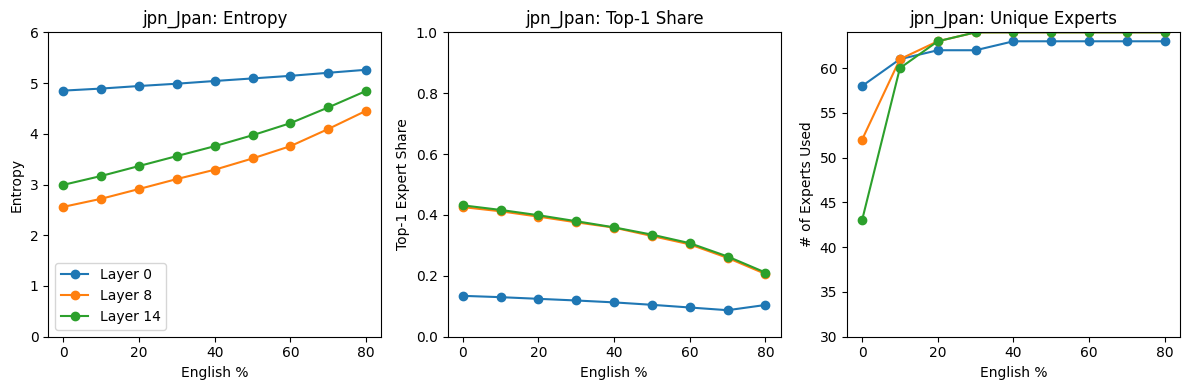

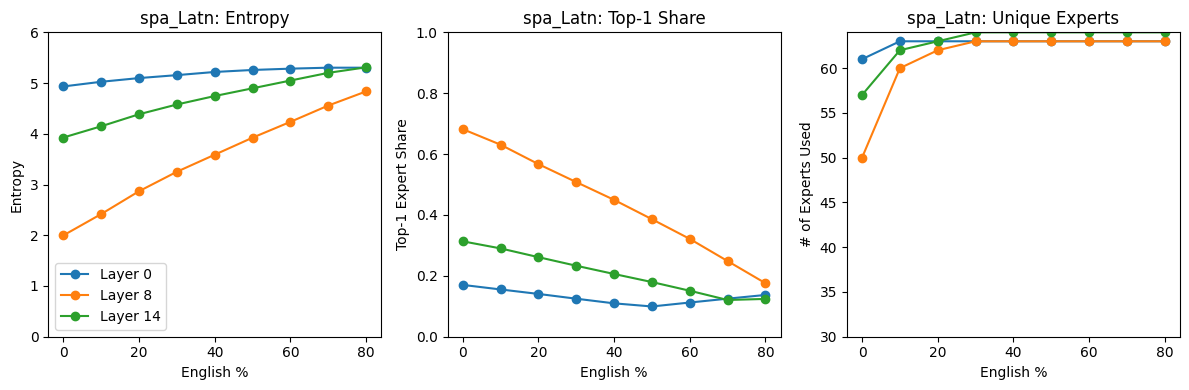

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]
target_langs = ["bul_Cyrl", "kor_Hang", "jpn_Jpan", "spa_Latn"]

layers = [
    "model.layers.0.mlp.gate",
    "model.layers.8.mlp.gate",
    "model.layers.14.mlp.gate"
]

layer_labels = {
    "model.layers.0.mlp.gate": "Layer 0",
    "model.layers.8.mlp.gate": "Layer 8",
    "model.layers.14.mlp.gate": "Layer 14"
}

def compute_entropy(counts):
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

for tgt in target_langs:

    plt.figure(figsize=(12, 4))

    # Entropy
    plt.subplot(1, 3, 1)

    for layer in layers:
        entropies = []

        for r in ratios:
            df = pd.read_csv(f"router_logs_{tgt}_{r}_layers.csv")
            sub = df[df["layer"] == layer]

            counts = sub["expert_id"].value_counts()
            entropies.append(compute_entropy(counts.values))

        plt.plot(ratios, entropies, marker='o', label=layer_labels[layer])

    plt.title(f"{tgt}: Entropy")
    plt.xlabel("English %")
    plt.ylabel("Entropy")
    plt.ylim(0,6)
    plt.legend()

    # Top-1 share
    plt.subplot(1, 3, 2)

    for layer in layers:
        top1 = []

        for r in ratios:
            df = pd.read_csv(f"router_logs_{tgt}_{r}_layers.csv")
            sub = df[df["layer"] == layer]

            counts = sub["expert_id"].value_counts()
            top1.append(counts.iloc[0] / counts.sum())

        plt.plot(ratios, top1, marker='o', label=layer_labels[layer])

    plt.title(f"{tgt}: Top-1 Share")
    plt.xlabel("English %")
    plt.ylabel("Top-1 Expert Share")
    plt.ylim(0,1)

    # Unique experts
    plt.subplot(1, 3, 3)

    for layer in layers:
        unique = []

        for r in ratios:
            df = pd.read_csv(f"router_logs_{tgt}_{r}_layers.csv")
            sub = df[df["layer"] == layer]

            counts = sub["expert_id"].value_counts()
            unique.append(len(counts))

        plt.plot(ratios, unique, marker='o', label=layer_labels[layer])

    plt.title(f"{tgt}: Unique Experts")
    plt.xlabel("English %")
    plt.ylabel("# of Experts Used")
    plt.ylim(30,64)

    plt.tight_layout()
    plt.show()